In [11]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [12]:
np.random.seed(42)
normal_data = np.random.normal(50,10,100)
outliers = [150,200,250]
data = np.concatenate([normal_data,outliers])
df = pd.DataFrame({"value": data})
print("outliers data :")
display(df.describe())

outliers data :


,value
count,103.000000
mean,53.360713
std,27.937209
min,23.802549
25%,44.185369
50%,49.279899
75%,55.279137
max,250.000000


Text(0.5, 1.0, 'Histogram with outlier')

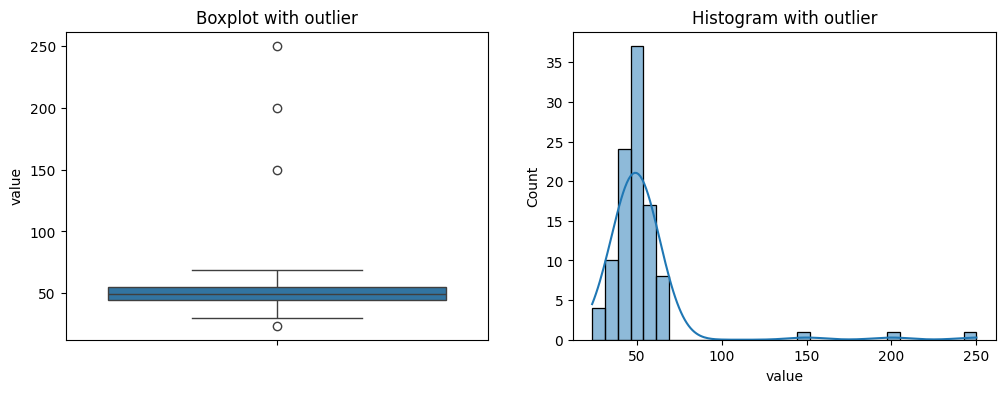

In [13]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['value'])
plt.title("Boxplot with outlier")

plt.subplot(1,2,2)
sns.histplot(df['value'],bins=30 ,kde=True)
plt.title("Histogram with outlier")

 1 method of removing outliers by using z_scores

In [14]:
# Detect Outlier
# using z-scores 

z_scores = np.abs(stats.zscore(df['value']))
df['z_outlier'] = z_scores > 3


# using IQR
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5* IQR

df['iqr_outlier'] = (df['value'] < lower_bound) | (df['value'] > upper_bound)

print("\n Outlier Detection(first 10 rows):")
display(df.tail(10))



 Outlier Detection(first 10 rows):


,value,z_outlier,iqr_outlier
93,46.723379,False,False
94,46.078918,False,False
95,35.364851,False,False
96,52.961203,False,False
97,52.610553,False,False
98,50.051135,False,False
99,47.654129,False,False
100,150.000000,True,True
101,200.000000,True,True
102,250.000000,True,True


Handling  outliers

In [15]:
# a) Remove Outlier (IQR method)

df_removed = df[~df['iqr_outlier']]


#b)Cap Outlier (Winsorization)

df_capped =df.copy()
df_capped['valued'] = np.where(df_capped['value'] > upper_bound ,upper_bound,
                                np.where(df_capped['value']< lower_bound,lower_bound,df_capped['value']))

5. Visualization After Handling

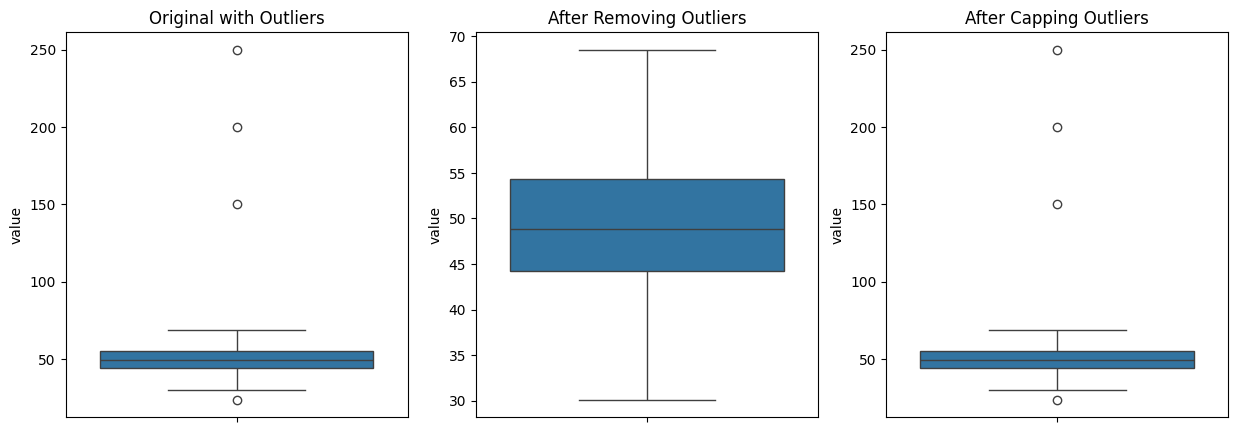

In [17]:
fig ,axes = plt.subplots(1,3, figsize =(15,5))

sns.boxplot(y=df['value'],ax= axes[0])
axes[0].set_title("Original with Outliers")

sns.boxplot(y=df_removed['value'],ax= axes[1])
axes[1].set_title("After Removing Outliers")

sns.boxplot(y=df_capped['value'],ax= axes[2])
axes[2].set_title("After Capping Outliers")

plt.show()